In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [17]:
# --- config
PROJECT = "telecom3_hybrid_segmentation"
EXP_AUDIT = f"{PROJECT}_feature_audit"
EXP_CLUST = f"{PROJECT}_segmentation"
EXP_MODEL = f"{PROJECT}_modeling"

SEED = 108

import mlflow
mlflow.set_experiment(EXP_AUDIT)  

MlflowException: Cannot set a deleted experiment 'telecom3_hybrid_segmentation_feature_audit' as the active experiment. You can restore the experiment, or permanently delete the experiment to create a new one.

In [14]:
import mlflow
print("Tracking URI:", mlflow.get_tracking_uri())


Tracking URI: file:///C:/Users/argon/Documents/Desktop%20Prime/MS%20Business%20Analytics/mlruns


In [15]:
import mlflow
mlflow.set_experiment("telecom3_hybrid_segmentation_feature_audit")

with mlflow.start_run(run_name="smoketest_v1"):
    mlflow.log_param("seed", 108)
    mlflow.log_metric("ping", 1.0)

print("Done. Experiment ID:", mlflow.get_experiment_by_name("telecom3_hybrid_segmentation_feature_audit").experiment_id)


Done. Experiment ID: 205050855668436152


# 1. Load & Basic Prep

In [5]:
df_raw = pd.read_csv(r"C:\Users\argon\Documents\Desktop Prime\MS Business Analytics\Fall Semester\Marketing Analytics\Modified_Telco_Customer_Churn_Updated.csv")

print(df_raw.shape)
print(df_raw.dtypes.value_counts())

print('Basic Information')

df_raw.info

(7043, 22)
int64      15
object      4
float64     3
Name: count, dtype: int64
Basic Information


<bound method DataFrame.info of       customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0     7590-VHVEG       0              0        1           0       1   
1     5575-GNVDE       1              0        0           0      34   
2     3668-QPYBK       1              0        0           0       2   
3     7795-CFOCW       1              0        0           0      45   
4     9237-HQITU       0              0        0           0       2   
...          ...     ...            ...      ...         ...     ...   
7038  6840-RESVB       1              0        1           1      24   
7039  2234-XADUH       0              0        1           1      72   
7040  4801-JZAZL       0              0        1           1      11   
7041  8361-LTMKD       1              1        1           0       4   
7042  3186-AJIEK       1              0        0           0      66   

      PhoneService  MultipleLines InternetService  OnlineSecurity  ...  \
0                0           

In [3]:
df_raw['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [6]:
# column groups (explicit > implicit)
ID_COLS = ['customerID']
TARGET  = 'Churn'

BINARY_COLS = [
    'gender','SeniorCitizen','Partner','Dependents',
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'PaperlessBilling','Churn'
]

CAT_COLS = ['InternetService','Contract','PaymentMethod']   # keep as strings for modeling
NUM_BASE = ['tenure','AvgChargesPerMonth','MonthlyCharges','TotalCharges']

# 2. Basic Cleaning

In [8]:
df_base = df_raw.copy()

# types
df_base['TotalCharges'] = pd.to_numeric(df_base['TotalCharges'], errors='coerce')
for c in BINARY_COLS:
    df_base[c] = df_base[c].astype(int)

In [9]:
df_base['tenure_bin'] = pd.cut(
    df_base['tenure'],
    bins=[0,12,24,36,48,60,np.inf],
    labels=['0-1y','1-2y','2-3y','3-4y','4-5y','5y+']
)

# tenure-bucket median imputation for numeric spend columns
for col in ['TotalCharges','AvgChargesPerMonth','MonthlyCharges']:
    df_base[col] = df_base.groupby('tenure_bin')[col].transform(lambda x: x.fillna(x.median()))
    df_base[col] = df_base[col].fillna(df_base[col].median())  # final fallback

# quick check
print("NA counts (df_base):")
print(df_base[NUM_BASE + ['tenure_bin']].isna().sum())

NA counts (df_base):
tenure                 0
AvgChargesPerMonth     0
MonthlyCharges         0
TotalCharges           0
tenure_bin            11
dtype: int64


# 3. Feature Audit

In [12]:
df_audit = df_base.copy()
# engineered
df_audit["CLV"] = df_audit["tenure"] * df_audit["MonthlyCharges"]
df_audit["CLV_per_month"] = df_audit["CLV"] / np.where(df_audit["tenure"]>0, df_audit["tenure"], 1)
df_audit["ChargeTrend"] = df_audit["MonthlyCharges"] / (df_audit["tenure"] + 1)
df_audit["FamilySupport"] = df_audit["Partner"] + df_audit["Dependents"]
SERVICE_ADDONS = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
df_audit["NumAddOns"] = df_audit[SERVICE_ADDONS].sum(axis=1)
df_audit["TotalServices"] = df_audit[["PhoneService","MultipleLines"] + SERVICE_ADDONS].sum(axis=1)

# EDA-only target enc
for col in ["Contract","PaymentMethod","InternetService"]:
    df_audit[f"{col}_churn_encoded"] = df_audit[col].map(df_audit.groupby(col)[TARGET].mean())
enc_cols = [c for c in df_audit.columns if c.endswith("_churn_encoded")]
df_audit[enc_cols] = df_audit[enc_cols].fillna(df_audit[TARGET].mean())

AUDIT_NUM_COLS = [
    "tenure","MonthlyCharges","AvgChargesPerMonth","TotalCharges",
    "CLV","CLV_per_month","ChargeTrend","FamilySupport","NumAddOns","TotalServices"
] + enc_cols


## 3.1 Feature Quality Dashboards

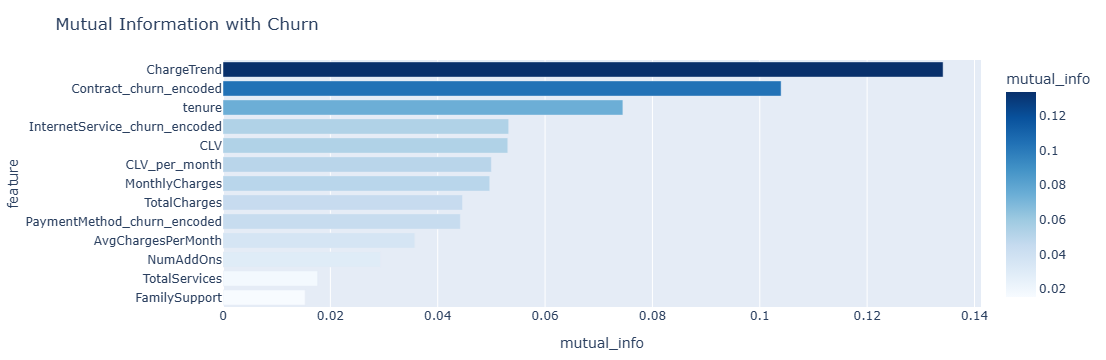

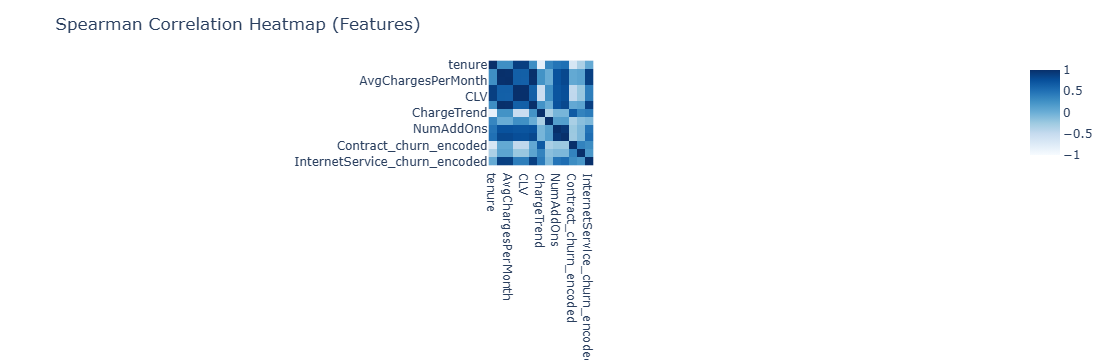

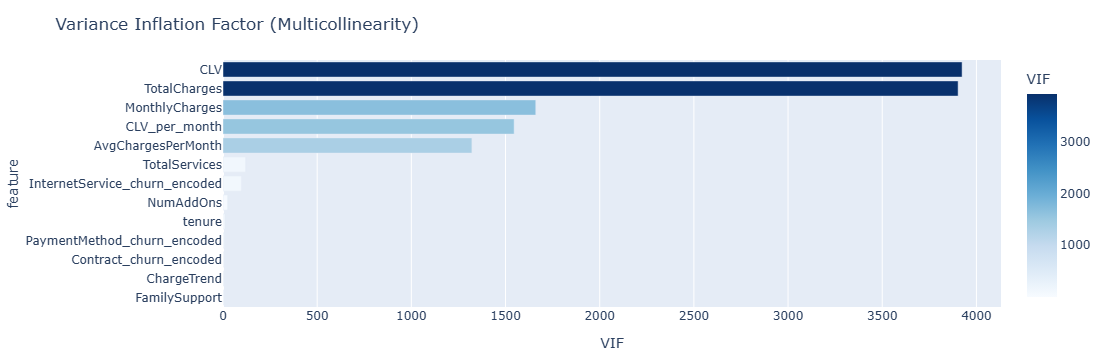

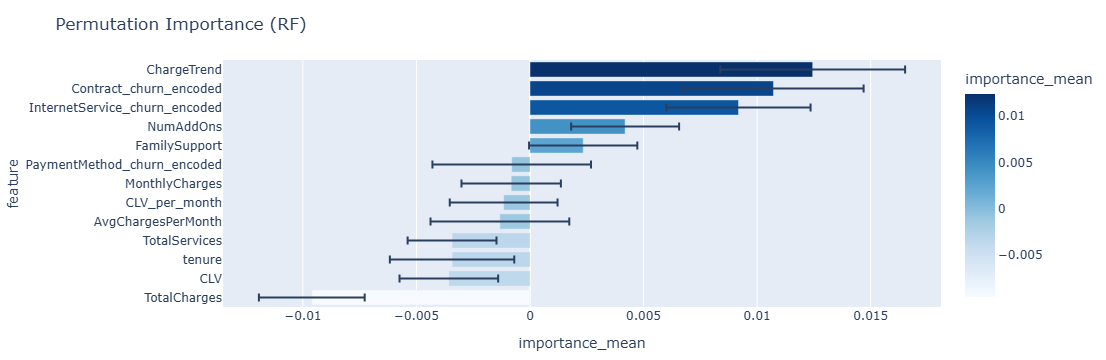

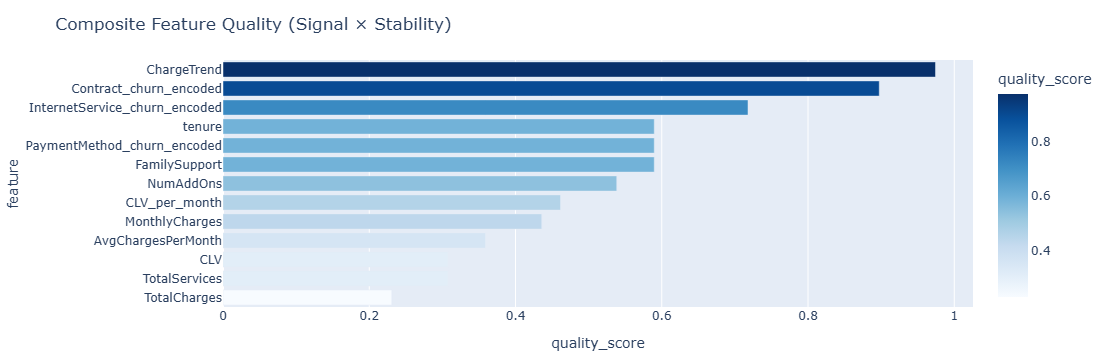

In [20]:
import plotly.express as px, numpy as np, pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tempfile, os

def show_and_log(fig, tmp_dir, fname, artifact_subdir="feature_audit"):
    """Render in-notebook AND log the HTML artifact to MLflow."""
    html_path = os.path.join(tmp_dir, f"{fname}.html")
    fig.write_html(html_path)
    fig.show()                          # <-- inline display
    mlflow.log_artifact(html_path, artifact_path=artifact_subdir)

mlflow.set_experiment(EXP_AUDIT)
with mlflow.start_run(run_name="feature_audit"):
    X = df_audit[AUDIT_NUM_COLS].fillna(0)
    y = df_audit[TARGET]

    tmp = tempfile.mkdtemp()

    # --- Mutual Information
    mi = mutual_info_classif(X, y, random_state=42)
    mi_df = (pd.DataFrame({"feature": X.columns, "mutual_info": mi})
             .sort_values("mutual_info"))
    fig_mi = px.bar(
        mi_df, x="mutual_info", y="feature", orientation="h",
        title="Mutual Information with Churn",
        color="mutual_info", color_continuous_scale="blues"  # changed palette
    )
    fig_mi.update_layout(yaxis=dict(categoryorder="total ascending"), margin=dict(l=120, r=30, t=60, b=30))
    show_and_log(fig_mi, tmp, "mi")

    # --- Spearman Correlation Heatmap
    corr = X.corr(method="spearman")
    fig_corr = px.imshow(
        corr, zmin=-1, zmax=1,
        color_continuous_scale="blues",                 # changed palette
        title="Spearman Correlation Heatmap (Features)"
    )
    fig_corr.update_layout(margin=dict(l=80, r=30, t=60, b=30))
    show_and_log(fig_corr, tmp, "corr")

    # --- VIF
    Xv = X + 1e-9 * np.random.RandomState(42).normal(size=X.shape)
    vif_df = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    }).sort_values("VIF")
    fig_vif = px.bar(
        vif_df, x="VIF", y="feature", orientation="h",
        title="Variance Inflation Factor (Multicollinearity)",
        color="VIF", color_continuous_scale="blues"      # changed palette
    )
    fig_vif.update_layout(yaxis=dict(categoryorder="total ascending"), margin=dict(l=120, r=30, t=60, b=30))
    show_and_log(fig_vif, tmp, "vif")

    # --- Permutation Importance (Random Forest)
    Xtr, Xte, ytr, yte = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xtr, ytr)
    perm = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=42)
    perm_df = (pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean"))
    fig_perm = px.bar(
        perm_df, x="importance_mean", y="feature", orientation="h",
        error_x="importance_std", title="Permutation Importance (RF)",
        color="importance_mean", color_continuous_scale="blues"   # changed palette
    )
    fig_perm.update_layout(yaxis=dict(categoryorder="total ascending"), margin=dict(l=120, r=30, t=60, b=30))
    show_and_log(fig_perm, tmp, "perm")

    # --- Composite Feature Quality
    merged = (mi_df.merge(vif_df, on="feature")
                    .merge(perm_df[["feature","importance_mean"]], on="feature"))
    merged["quality_score"] = (
        merged["mutual_info"].rank(pct=True) +
        merged["importance_mean"].rank(pct=True) +
        (1/np.clip(merged["VIF"], 1e-6, None)).rank(pct=True)
    ) / 3
    fig_score = px.bar(
        merged.sort_values("quality_score"),
        x="quality_score", y="feature", orientation="h",
        title="Composite Feature Quality (Signal × Stability)",
        color="quality_score", color_continuous_scale="blues"  # changed palette
    )
    fig_score.update_layout(yaxis=dict(categoryorder="total ascending"), margin=dict(l=120, r=30, t=60, b=30))
    show_and_log(fig_score, tmp, "quality")

    # --- Summary table artifact
    merged.to_csv(os.path.join(tmp, "feature_quality.csv"), index=False)
    mlflow.log_artifact(os.path.join(tmp, "feature_quality.csv"), artifact_path="feature_audit")


# 4. Freeze Feature Set

In [22]:
# --- make sure engineered columns exist on df_base ---
SERVICE_ADDONS = [
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"
]

# tenure_bin (if you haven't already)
if "tenure_bin" not in df_base.columns:
    df_base["tenure_bin"] = pd.cut(
        df_base["tenure"],
        bins=[0,12,24,36,48,60,float("inf")],
        labels=["0-1y","1-2y","2-3y","3-4y","4-5y","5y+"]
    )

# engineered features (same definitions you used for the charts)
df_base["NumAddOns"]   = df_base[SERVICE_ADDONS].sum(axis=1)
df_base["FamilySupport"] = df_base["Partner"] + df_base["Dependents"]
df_base["ChargeTrend"]  = df_base["MonthlyCharges"] / (df_base["tenure"] + 1)  # simple trend proxy

# optional: clip outliers a bit for stability (not required)
for c in ["ChargeTrend"]:
    lo, hi = df_base[c].quantile([0.01, 0.99])
    df_base[c] = df_base[c].clip(lo, hi)

print("engineered on df_base:", set(["ChargeTrend","NumAddOns","FamilySupport","tenure_bin"]) - set(df_base.columns))


engineered on df_base: set()


## 4.1 Column Lists

In [25]:
df_model_v1.info()  # <- real info

ID_COLS  = ["customerID"]
TARGET   = "Churn"

NUMS_V1  = ["tenure","ChargeTrend","NumAddOns","FamilySupport"]
CATS_V1  = ["Contract","InternetService","PaymentMethod","tenure_bin"]
BINS_V1  = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
            "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
            "StreamingTV","StreamingMovies","PaperlessBilling"]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   Churn             7043 non-null   int32   
 2   tenure            7043 non-null   int64   
 3   ChargeTrend       7043 non-null   float64 
 4   NumAddOns         7043 non-null   int64   
 5   FamilySupport     7043 non-null   int32   
 6   Contract          7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   PaymentMethod     7043 non-null   object  
 9   tenure_bin        7032 non-null   category
 10  gender            7043 non-null   int32   
 11  SeniorCitizen     7043 non-null   int32   
 12  Partner           7043 non-null   int32   
 13  Dependents        7043 non-null   int32   
 14  PhoneService      7043 non-null   int32   
 15  MultipleLines     7043 non-null   int32   
 16  OnlineSecurity    7043 n

In [30]:
df_model_v1 = df_model_v1.copy()
df_model_v1["tenure_bin"] = pd.cut(
    df_model_v1["tenure"],
    bins=[-1,12,24,36,48,60,10_000],  # include 0 by starting at -1
    labels=["0-1y","1-2y","2-3y","3-4y","4-5y","5y+"],
    include_lowest=True,
    right=True
)


## 4.2 Quick Clustering Check

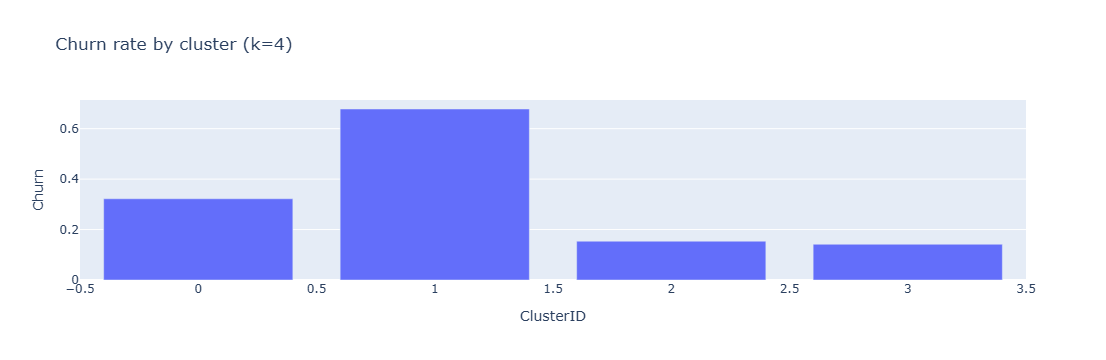

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

CLUST_NUMS = ["tenure","ChargeTrend","NumAddOns","FamilySupport"]
Xc = StandardScaler().fit_transform(df_model_v1[CLUST_NUMS])

sil = {}
for k in [2,3,4,5]:
    labels = KMeans(n_clusters=k, n_init=10, random_state=108).fit_predict(Xc)
    sil[k] = silhouette_score(Xc, labels)

best_k = max(sil, key=sil.get)
km_labels = KMeans(n_clusters=best_k, n_init=10, random_state=108).fit_predict(Xc)
df_model_v1["ClusterID"] = km_labels

# churn by cluster — if it separates, we can include ClusterID later
churn_by_cluster = df_model_v1.groupby("ClusterID")[TARGET].mean().reset_index()
px.bar(churn_by_cluster, x="ClusterID", y=TARGET, title=f"Churn rate by cluster (k={best_k})").show()


In [29]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
Xc = StandardScaler().fit_transform(df_model_v1[["tenure","ChargeTrend","NumAddOns","FamilySupport"]])
def metrics(labels):
    return dict(silhouette=silhouette_score(Xc, labels),
                calinski=calinski_harabasz_score(Xc, labels),
                davies=davies_bouldin_score(Xc, labels))
print("k=4 metrics:", metrics(df_model_v1["ClusterID"]))


k=4 metrics: {'silhouette': 0.33889625837741477, 'calinski': 4041.8913328461554, 'davies': 1.0344303712834408}


## 4.3 Cluster Profiling

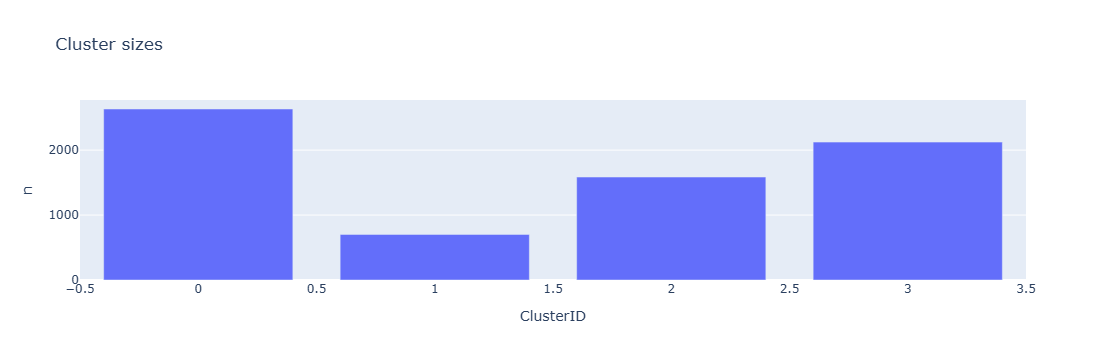

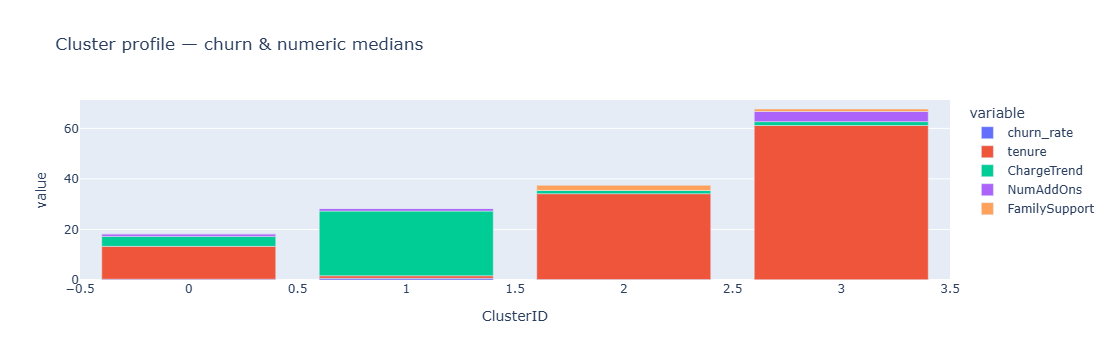

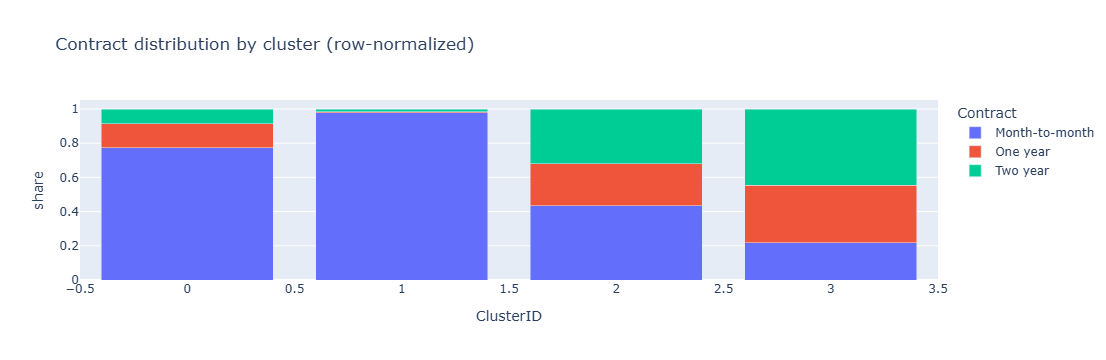

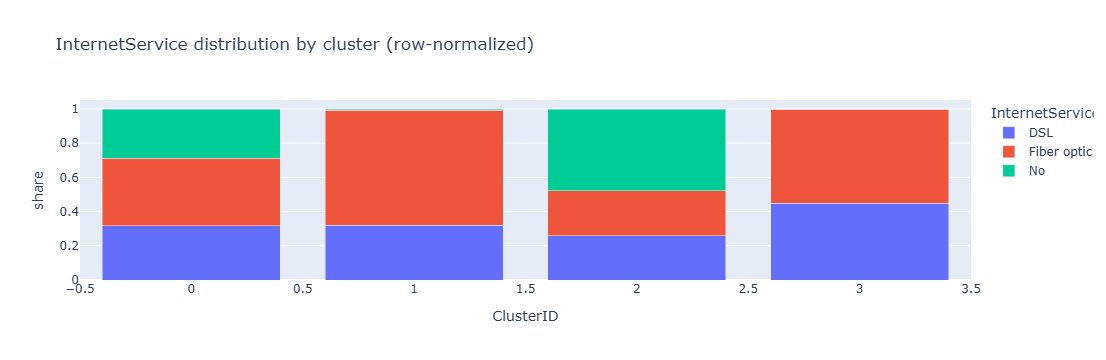

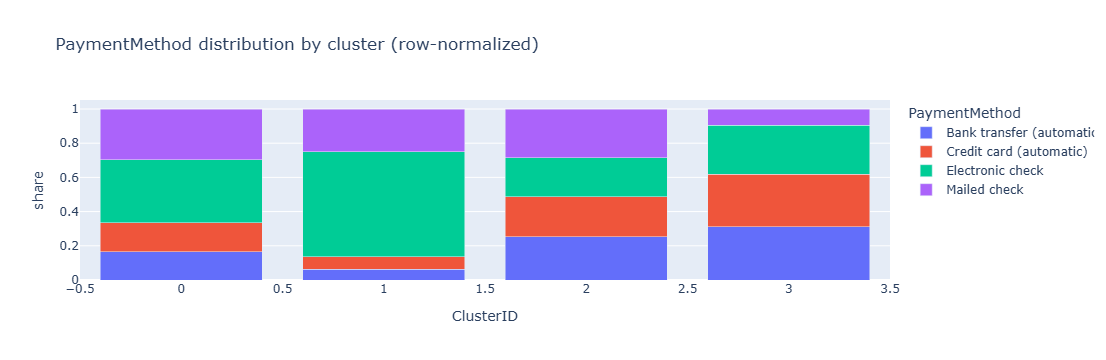

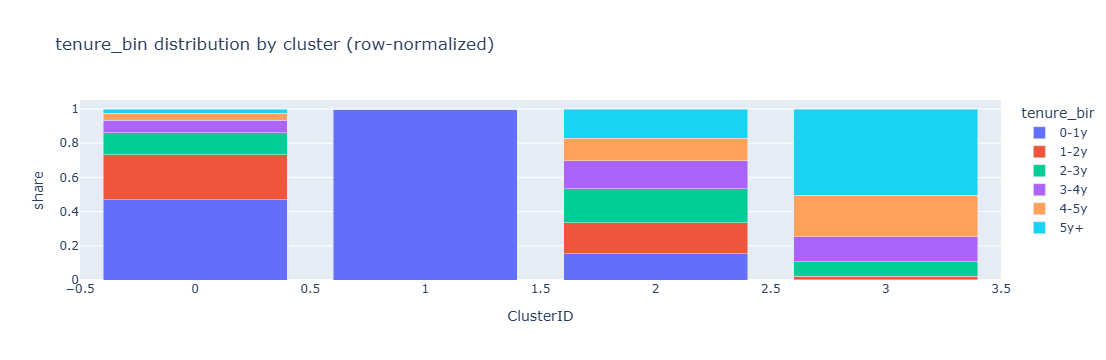

In [28]:
import pandas as pd, plotly.express as px

# sizes
sizes = df_model_v1.groupby("ClusterID").size().rename("n").reset_index()
px.bar(sizes, x="ClusterID", y="n", title="Cluster sizes").show()

# churn + numeric summaries
num_cols = ["tenure","ChargeTrend","NumAddOns","FamilySupport"]
prof_num = (df_model_v1
            .groupby("ClusterID")[["Churn"]+num_cols]
            .agg({"Churn":"mean", "tenure":"median", "ChargeTrend":"median",
                  "NumAddOns":"median","FamilySupport":"median"})
            .reset_index()
            .rename(columns={"Churn":"churn_rate"}))
px.bar(prof_num.melt("ClusterID"), x="ClusterID", y="value", color="variable",
       title="Cluster profile — churn & numeric medians").show()

for c in ["Contract", "InternetService", "PaymentMethod", "tenure_bin"]:
    # counts → row-normalized shares per cluster
    mix = (
        df_model_v1.groupby(["ClusterID", c]).size().unstack(fill_value=0)
        .pipe(lambda df: df.div(df.sum(axis=1), axis=0))               # row-normalize
        .reset_index()
        .melt("ClusterID", var_name=c, value_name="share")
    )
    px.bar(
        mix, x="ClusterID", y="share", color=c, barmode="stack",
        title=f"{c} distribution by cluster (row-normalized)"
    ).show()


## 4.4 Locking in Cluster Features

In [31]:
# Ensure tenure_bin has no NAs (you had ~11 from values at 0)
df_model_v1["tenure_bin"] = pd.cut(
    df_model_v1["tenure"],
    bins=[-1,12,24,36,48,60,10_000],
    labels=["0-1y","1-2y","2-3y","3-4y","4-5y","5y+"],
    include_lowest=True
)

# High-risk flag (use your computed churn_by_cluster)
churn_by_cluster = df_model_v1.groupby("ClusterID")["Churn"].mean()
HIGH_CLUSTER = churn_by_cluster.idxmax()
df_model_v1["HighRiskSegment"] = (df_model_v1["ClusterID"] == HIGH_CLUSTER).astype(int)


# 5. Baseline Modeling

In [32]:
import numpy as np, mlflow
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

# Reuse your lists from 4.1
NUMS_V1 = ["tenure","ChargeTrend","NumAddOns","FamilySupport"]
CATS_V1 = ["Contract","InternetService","PaymentMethod","tenure_bin"]
BINS_V1 = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
           "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
           "StreamingTV","StreamingMovies","PaperlessBilling"]

ID_COLS, TARGET = ["customerID"], "Churn"

def run_logreg_cv(df, nums, cats, bins, run_name, exp_name):
    X = df.drop(columns=ID_COLS + [TARGET]); y = df[TARGET].values
    prep = ColumnTransformer([
        ("num", StandardScaler(), nums),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cats),
        ("bin", "passthrough", bins),
    ], remainder="drop")
    pipe = Pipeline([("prep", prep),
                     ("clf", LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"))])
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
    y_p = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:,1]

    ap  = average_precision_score(y, y_p)
    roc = roc_auc_score(y, y_p)
    p,r,t = precision_recall_curve(y, y_p)
    f1 = 2*(p*r)/(p+r+1e-9); j = np.nanargmax(f1)
    thr = float(t[j]) if j < len(t) else 0.5

    mlflow.set_experiment(exp_name)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({"NUMS":",".join(nums), "CATS":",".join(cats), "BINS":",".join(bins)})
        mlflow.log_metrics({"avg_precision":float(ap), "roc_auc":float(roc), "best_f1":float(f1[j]), "best_thr":thr})
    print(f"{run_name} → AP={ap:.3f} | ROC={roc:.3f} | F1*={f1[j]:.3f} @ {thr:.3f}")

# A) Baseline (no cluster features)
run_logreg_cv(df_model_v1, NUMS_V1, CATS_V1, BINS_V1, run_name="logreg_v1__no_cluster", exp_name=EXP_MODEL)

# B) With clusters (hard label as categorical + high-risk flag)
NUMS_B = NUMS_V1
CATS_B = CATS_V1 + ["ClusterID"]
BINS_B = BINS_V1 + ["HighRiskSegment"]
run_logreg_cv(df_model_v1, NUMS_B, CATS_B, BINS_B, run_name="logreg_v1__with_cluster", exp_name=EXP_MODEL)


2025/10/13 13:02:17 INFO mlflow.tracking.fluent: Experiment with name 'telecom3_hybrid_segmentation_modeling' does not exist. Creating a new experiment.


logreg_v1__no_cluster → AP=0.667 | ROC=0.849 | F1*=0.637 @ 0.589
logreg_v1__with_cluster → AP=0.667 | ROC=0.849 | F1*=0.636 @ 0.586


## 5.1 Soft Segmentation

In [33]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

Xc = StandardScaler().fit_transform(df_model_v1[["tenure","ChargeTrend","NumAddOns","FamilySupport"]])
gmm = GaussianMixture(n_components=df_model_v1["ClusterID"].nunique(), random_state=108).fit(Xc)
probs = gmm.predict_proba(Xc)
for i in range(probs.shape[1]):
    df_model_v1[f"ClusterProb_{i}"] = probs[:, i]

NUMS_P = NUMS_V1 + [f"ClusterProb_{i}" for i in range(probs.shape[1])]
run_logreg_cv(df_model_v1, NUMS_P, CATS_V1, BINS_V1, run_name="logreg_v1__cluster_probs", exp_name=EXP_MODEL)


logreg_v1__cluster_probs → AP=0.666 | ROC=0.848 | F1*=0.635 @ 0.591


# Running Tests

In [34]:
import numpy as np, mlflow
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

X_all = df_model_v1.drop(columns=["customerID","Churn"])
y_all = df_model_v1["Churn"].values

NUMS = ["tenure","ChargeTrend","NumAddOns","FamilySupport"]
CATS = ["Contract","InternetService","PaymentMethod","tenure_bin"]
BINS = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
        "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
        "StreamingTV","StreamingMovies","PaperlessBilling"]

def eval_pipe(prep, clf, run_name, exp):
    mlflow.set_experiment(exp)
    with mlflow.start_run(run_name=run_name):
        pipe = Pipeline([("prep", prep), ("clf", clf)])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
        p = cross_val_predict(pipe, X_all, y_all, cv=cv, method="predict_proba")[:,1]
        ap, roc = average_precision_score(y_all, p), roc_auc_score(y_all, p)
        pr, rc, th = precision_recall_curve(y_all, p)
        f1 = 2*(pr*rc)/(pr+rc+1e-9); j = np.nanargmax(f1)
        thr = float(th[j]) if j < len(th) else 0.5
        mlflow.log_metrics({"avg_precision":float(ap), "roc_auc":float(roc),
                            "best_f1":float(f1[j]), "best_thr":thr})
        print(f"{run_name}: AP={ap:.3f} | ROC={roc:.3f} | F1*={f1[j]:.3f} @ {thr:.3f}")
        return p, ap

# ---- T1: Target Encoding vs One-Hot ----
try:
    import category_encoders as ce
    te = ce.TargetEncoder(cols=CATS, smoothing=10.0)
    prep_te = ColumnTransformer([
        ("te", te, CATS),
        ("num", StandardScaler(), NUMS),
        ("bin", "passthrough", BINS),
    ], remainder="drop")
    p_te, ap_te = eval_pipe(prep_te,
                            LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"),
                            run_name="logreg_TE_v1", exp="telecom3_hybrid_segmentation_modeling")
except Exception as e:
    print("TargetEncoder not available; skipping T1.", e)
    p_te, ap_te = None, None

# Baseline One-Hot (for reference inside the grid)
prep_oh = ColumnTransformer([
    ("num", StandardScaler(), NUMS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATS),
    ("bin", "passthrough", BINS),
], remainder="drop")
p_oh, ap_oh = eval_pipe(prep_oh,
                        LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"),
                        run_name="logreg_OH_v1", exp="telecom3_hybrid_segmentation_modeling")

# ---- T2: Add non-linear capacity (same features) ----
p_gb, ap_gb = eval_pipe(prep_oh,
                        GradientBoostingClassifier(random_state=108),
                        run_name="gboost_OH_v1", exp="telecom3_hybrid_segmentation_modeling")

# ---- T3: Numeric ablation (redundancy check) ----
for drop in NUMS:
    keep = [c for c in NUMS if c != drop]
    prep_drop = ColumnTransformer([
        ("num", StandardScaler(), keep),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATS),
        ("bin", "passthrough", BINS),
    ], remainder="drop")
    _, ap_drop = eval_pipe(prep_drop,
                           LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"),
                           run_name=f"logreg_OH_minus_{drop}", exp="telecom3_hybrid_segmentation_modeling")


TargetEncoder not available; skipping T1. No module named 'category_encoders'
logreg_OH_v1: AP=0.667 | ROC=0.849 | F1*=0.637 @ 0.589
gboost_OH_v1: AP=0.670 | ROC=0.849 | F1*=0.636 @ 0.308
logreg_OH_minus_tenure: AP=0.664 | ROC=0.847 | F1*=0.640 @ 0.567
logreg_OH_minus_ChargeTrend: AP=0.662 | ROC=0.848 | F1*=0.634 @ 0.516
logreg_OH_minus_NumAddOns: AP=0.667 | ROC=0.849 | F1*=0.637 @ 0.589
logreg_OH_minus_FamilySupport: AP=0.667 | ROC=0.849 | F1*=0.637 @ 0.589


In [35]:
# === Unified Modeling Harness: LogReg / GradBoost / XGBoost (optional) ===
import numpy as np, pandas as pd, mlflow
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# --------- 0) Feature spec (your lean Feature Set v1.1) ----------
NUMS = ["tenure","ChargeTrend"]
CATS = ["Contract","InternetService","PaymentMethod","tenure_bin"]
BINS = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
        "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
        "StreamingTV","StreamingMovies","PaperlessBilling"]

X = df_model_v1.drop(columns=["customerID","Churn"])
y = df_model_v1["Churn"].values
pos_w = float((len(y)-y.sum())/y.sum())  # for XGB imbalance handling

# Common preprocessor
prep = ColumnTransformer([
    ("num", StandardScaler(), NUMS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATS),
    ("bin", "passthrough", BINS),
], remainder="drop")

# --------- 1) Model zoo (defines ALL candidates here) ----------
models = {
    "logreg": LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"),
    "gboost": GradientBoostingClassifier(random_state=108),
}

# Try to add XGBoost if available
try:
    from xgboost import XGBClassifier
    models["xgb_baseline"] = XGBClassifier(
        n_estimators=400, learning_rate=0.10, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=108, n_jobs=-1, tree_method="hist", eval_metric="logloss",
        scale_pos_weight=pos_w
    )
    models["xgb_tuned"] = XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=108, n_jobs=-1, tree_method="hist", eval_metric="logloss",
        scale_pos_weight=pos_w
    )
except Exception as e:
    print("XGBoost not available (pip install xgboost to enable). Skipping XGB. Error:", e)

# --------- 2) Repeated-CV evaluator + MLflow logging ----------
def eval_repeated_cv(name, clf, n_splits=5, n_repeats=5, seed=108, exp_name=EXP_MODEL):
    aps, rocs = [], []
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    for tr, te in rskf.split(X, y):
        pipe = Pipeline([("prep", prep), ("clf", clf)])
        y_prob = pipe.fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:,1]
        aps.append(average_precision_score(y[te], y_prob))
        rocs.append(roc_auc_score(y[te], y_prob))
    ap_mean, ap_std = float(np.mean(aps)), float(np.std(aps))
    roc_mean, roc_std = float(np.mean(rocs)), float(np.std(rocs))

    mlflow.set_experiment(exp_name)
    with mlflow.start_run(run_name=f"{name}__repeatedCV"):
        mlflow.log_metrics({
            "avg_precision_mean": ap_mean, "avg_precision_std": ap_std,
            "roc_auc_mean": roc_mean,     "roc_auc_std": roc_std
        })
        # log key params if the estimator exposes them
        try:
            mlflow.log_params({k:str(v) for k,v in clf.get_params().items()
                               if k in ["n_estimators","learning_rate","max_depth",
                                        "subsample","colsample_bytree","reg_lambda",
                                        "class_weight","solver","scale_pos_weight"]})
        except Exception:
            pass

    print(f"{name}:  AP {ap_mean:.3f} ± {ap_std:.003f} | ROC {roc_mean:.3f} ± {roc_std:.003f}")
    return ap_mean, roc_mean

# Run all candidates + collect leaderboard
leaderboard = []
for name, clf in models.items():
    ap, roc = eval_repeated_cv(name, clf)
    leaderboard.append({"model": name, "AP_mean": ap, "ROC_mean": roc})

leaderboard = pd.DataFrame(leaderboard).sort_values(["AP_mean","ROC_mean"], ascending=False)
print("\nLeaderboard (repeated-CV):")
display(leaderboard)

# --------- 3) Pick best & compute CV probabilities for thresholding ----------
best_name = leaderboard.iloc[0]["model"]
best_clf = models[best_name]
print(f"\nChosen model: {best_name}")

pipe_best = Pipeline([("prep", prep), ("clf", best_clf)])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
y_prob_cv = cross_val_predict(pipe_best, X, y, cv=cv, method="predict_proba")[:,1]

def threshold_for_precision(y_true, y_prob, min_precision=0.30):
    p, r, t = precision_recall_curve(y_true, y_prob)
    ok = p >= min_precision
    if not np.any(ok):
        f1 = 2*(p*r)/(p+r+1e-9); j = np.nanargmax(f1)
        thr = t[j] if j < len(t) else 0.5
        return float(thr), float(p[j]), float(r[j]), float((y_prob>=thr).mean())
    j = np.argmax(r[ok])
    thr = t[ok][j] if j < ok.sum() else 0.5
    return float(thr), float(p[ok][j]), float(r[ok][j]), float((y_prob>=thr).mean())

thr, prec, rec, flagged = threshold_for_precision(y, y_prob_cv, min_precision=0.30)
print(f"Operating point (≥30% precision): threshold={thr:.3f} → precision={prec:.3f}, recall={rec:.3f}, flagged rate={flagged:.3f}")

# Log the chosen operating point to MLflow
mlflow.set_experiment(EXP_MODEL)
with mlflow.start_run(run_name=f"{best_name}__threshold@p30"):
    mlflow.log_metric("chosen_threshold_p30", thr)
    mlflow.log_metric("precision_at_p30", prec)
    mlflow.log_metric("recall_at_p30", rec)
    mlflow.log_metric("flagged_rate_at_p30", flagged)


logreg:  AP 0.669 ± 0.024 | ROC 0.848 ± 0.010
gboost:  AP 0.670 ± 0.020 | ROC 0.849 ± 0.008
xgb_baseline:  AP 0.641 ± 0.022 | ROC 0.832 ± 0.008
xgb_tuned:  AP 0.641 ± 0.022 | ROC 0.833 ± 0.007

Leaderboard (repeated-CV):


,model,AP_mean,ROC_mean
1,gboost,0.670289,0.848578
0,logreg,0.669107,0.848497
3,xgb_tuned,0.641485,0.833179
2,xgb_baseline,0.641223,0.832467



Chosen model: gboost


IndexError: boolean index did not match indexed array along dimension 0; dimension is 6589 but corresponding boolean dimension is 6590

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np, mlflow

# Use your chosen winner (you picked GradientBoosting)
winner = GradientBoostingClassifier(random_state=108)

pipe_best = Pipeline([("prep", prep), ("clf", winner)])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
y_prob_cv = cross_val_predict(pipe_best, X, y, cv=cv, method="predict_proba")[:, 1]

def threshold_for_precision(y_true, y_prob, min_precision=0.30):
    # PR curve
    p, r, t = precision_recall_curve(y_true, y_prob)
    # Align lengths: thresholds t has length len(p) - 1
    p_, r_, t_ = p[:-1], r[:-1], t

    # Try to meet the precision constraint
    ok = p_ >= min_precision
    if np.any(ok):
        j = np.argmax(r_[ok])                # highest recall while meeting precision
        thr = float(t_[ok][j])
        prec, rec = float(p_[ok][j]), float(r_[ok][j])
        rate = float((y_prob >= thr).mean())
        return thr, prec, rec, rate, "precision_constrained"

    # Fallback: best F1 across feasible thresholds
    f1 = 2 * (p_ * r_) / (p_ + r_ + 1e-9)
    j = int(np.nanargmax(f1))
    thr = float(t_[j]); prec, rec = float(p_[j]), float(r_[j])
    rate = float((y_prob >= thr).mean())
    return thr, prec, rec, rate, "best_f1_fallback"

thr, prec, rec, flagged, rule = threshold_for_precision(y, y_prob_cv, min_precision=0.30)
print(f"Rule={rule} | threshold={thr:.3f} → precision={prec:.3f}, recall={rec:.3f}, flagged rate={flagged:.3f}")

# Log to MLflow
mlflow.set_experiment(EXP_MODEL)
with mlflow.start_run(run_name=f"gboost__threshold@p30_fixed"):
    mlflow.log_metric("chosen_threshold_p30", thr)
    mlflow.log_metric("precision_at_p30", prec)
    mlflow.log_metric("recall_at_p30", rec)
    mlflow.log_metric("flagged_rate_at_p30", flagged)
    mlflow.log_param("threshold_rule", rule)


Rule=precision_constrained | threshold=0.021 → precision=0.300, recall=0.995, flagged rate=0.880


In [38]:
import numpy as np, pandas as pd
from sklearn.metrics import precision_recall_curve

def threshold_grid(y_true, y_prob, precision_targets=(0.30,0.35,0.40), rate_caps=(0.10,0.15,0.20,0.25)):
    p, r, t = precision_recall_curve(y_true, y_prob)
    # align to thresholds
    p, r, t = p[:-1], r[:-1], t
    rows=[]
    for pmin in precision_targets:
        ok = p >= pmin
        if not np.any(ok):
            rows.append({"policy": f"prec≥{pmin:.2f}", "thr": np.nan, "precision": np.nan, "recall": np.nan, "flagged_rate": np.nan})
            continue
        # evaluate flagged rate at each feasible threshold
        flagged_rates = np.array([(y_prob >= th).mean() for th in t[ok]])
        # try caps ascending; pick highest recall meeting the tightest cap available
        picked=None
        for cap in sorted(rate_caps):
            meet = flagged_rates <= cap
            if np.any(meet):
                idx = np.argmax(r[ok][meet])   # max recall among those meeting the cap
                picked = dict(policy=f"prec≥{pmin:.2f} & rate≤{cap:.2f}",
                              thr=float(t[ok][meet][idx]),
                              precision=float(p[ok][meet][idx]),
                              recall=float(r[ok][meet][idx]),
                              flagged_rate=float(flagged_rates[meet][idx]))
                break
        # if none meet any cap, take best recall at that precision floor (no cap)
        if picked is None:
            idx = np.argmax(r[ok])
            picked = dict(policy=f"prec≥{pmin:.2f} (no cap)", thr=float(t[ok][idx]),
                          precision=float(p[ok][idx]), recall=float(r[ok][idx]),
                          flagged_rate=float((y_prob >= t[ok][idx]).mean()))
        rows.append(picked)
    return pd.DataFrame(rows)

grid = threshold_grid(y, y_prob_cv, precision_targets=(0.30,0.35,0.40), rate_caps=(0.10,0.15,0.20,0.25))
grid


,policy,thr,precision,recall,flagged_rate
0,prec≥0.30 & rate≤0.10,0.660718,0.775568,0.292135,0.099957
1,prec≥0.35 & rate≤0.10,0.660718,0.775568,0.292135,0.099957
2,prec≥0.40 & rate≤0.10,0.660718,0.775568,0.292135,0.099957


In [39]:
def threshold_for_quota(y_prob, top_rate=0.15):  # e.g., 15% of customers
    k = max(1, int(len(y_prob) * top_rate))
    thr = float(np.partition(y_prob, -k)[-k])  # k-th largest value
    return thr

thr_q = threshold_for_quota(y_prob_cv, top_rate=0.15)
pred_q = (y_prob_cv >= thr_q).astype(int)

from sklearn.metrics import precision_score, recall_score
print("Quota 15% → thr={:.4f} | precision={:.3f} | recall={:.3f} | flagged_rate={:.3f}"
      .format(thr_q,
              precision_score(y, pred_q, zero_division=0),
              recall_score(y, pred_q, zero_division=0),
              pred_q.mean()))


Quota 15% → thr=0.5803 | precision=0.717 | recall=0.405 | flagged_rate=0.150


In [40]:
# assuming you have df_model_v1["CLV"] or similar (else skip or set all CLV=1)
clv = df_model_v1.get("CLV", pd.Series(np.ones_like(y_prob_cv), index=df_model_v1.index)).values

def choose_by_cost(y_true, y_prob, clv, c_fp=1.0, c_fn_per_clv=0.1):
    """
    c_fp: cost to contact a non-churner (per customer)
    c_fn_per_clv: cost of missing a churner as fraction of CLV (e.g., 0.1 = 10% of CLV)
    """
    p, r, t = precision_recall_curve(y_true, y_prob); p, r, t = p[:-1], r[:-1], t
    best = None
    for thr in t:
        pred = (y_prob >= thr).astype(int)
        fp = ((pred==1) & (y_true==0)).sum() * c_fp
        fn = clv[((pred==0) & (y_true==1))].sum() * c_fn_per_clv
        total = fp + fn
        if (best is None) or (total < best[0]):
            best = (total, thr)
    total_cost, thr = best
    return float(thr), float(total_cost)

thr_cost, total_cost = choose_by_cost(y, y_prob_cv, clv, c_fp=1.0, c_fn_per_clv=0.1)
print(f"Cost-optimal thr={thr_cost:.4f} (total expected cost={total_cost:.1f})")


Cost-optimal thr=0.9010 (total expected cost=185.5)


In [41]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

def report_at_threshold(y_true, y_prob, thr):
    pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    n = len(y_true)
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)
    flagged = pred.mean()
    print(f"thr={thr:.4f} | precision={prec:.3f} | recall={rec:.3f} | flagged_rate={flagged:.3f}")
    print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn} (n={n})")

# example with a tighter policy:
thr_final = grid.loc[grid['policy']=='prec≥0.35 & rate≤0.20','thr'].iloc[0] if ('prec≥0.35 & rate≤0.20' in set(grid['policy'])) else thr
report_at_threshold(y, y_prob_cv, thr_final)


thr=0.0208 | precision=0.300 | recall=0.995 | flagged_rate=0.880
TP=1859  FP=4337  FN=10  TN=837 (n=7043)


# Solely Model Improvement Now

In [46]:
# --- CV-safe Target Encoder (sklearn-clone friendly) ---
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Mean target encoding with smoothing. Safe for ColumnTransformer + CV.
    - __init__ does NOT modify params (so sklearn.clone works).
    - Internals live in *_ attributes set at fit time.
    - Unseen categories -> global prior.
    """
    def __init__(self, cols=None, smoothing=10.0):
        self.cols = cols
        self.smoothing = smoothing

    def fit(self, X, y):
        # columns passed by ColumnTransformer -> X is ndarray or DataFrame slice
        # Store fitted artifacts on *_ attributes
        self.cols_ = list(self.cols) if self.cols is not None else [f"c{i}" for i in range(X.shape[1])]
        X_df = pd.DataFrame(X, columns=self.cols_)
        y = pd.Series(y, dtype="float64")

        self.prior_ = float(y.mean())
        self.maps_ = {}
        smooth = float(self.smoothing)

        for c in self.cols_:
            s = X_df[c].astype("string")  # robust to Categorical
            grp = pd.DataFrame({"y": y, c: s}).groupby(c, dropna=False)["y"].agg(["mean","count"])
            m = (grp["count"]*grp["mean"] + smooth*self.prior_) / (grp["count"] + smooth)
            self.maps_[c] = m.to_dict()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.cols_)
        out = []
        for c in self.cols_:
            s = X_df[c].astype("string")
            enc = s.map(self.maps_[c])
            enc = pd.to_numeric(enc, errors="coerce").fillna(self.prior_).astype("float64").to_numpy().reshape(-1,1)
            out.append(enc)
        return np.hstack(out)


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

NUMS = ["tenure","ChargeTrend"]
CATS = ["Contract","InternetService","PaymentMethod","tenure_bin"]
BINS = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
        "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
        "StreamingTV","StreamingMovies","PaperlessBilling"]

X = df_model_v1.drop(columns=["customerID","Churn"])
y = df_model_v1["Churn"].values

prep_te = ColumnTransformer([
    ("num", StandardScaler(), NUMS),
    ("cat_te", KFoldTargetEncoder(cols=CATS, smoothing=10.0), CATS),
    ("bin", "passthrough", BINS),
], remainder="drop")

pipe_te_lr = Pipeline([
    ("prep", prep_te),
    ("clf", LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"))
])

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=108)
aps, rocs = [], []
for tr, te in rskf.split(X, y):
    y_prob = pipe_te_lr.fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:,1]
    aps.append(average_precision_score(y[te], y_prob))
    rocs.append(roc_auc_score(y[te], y_prob))
print(f"LogReg + KFold TE → AP {np.mean(aps):.3f} ± {np.std(aps):.003f} | ROC {np.mean(rocs):.3f} ± {np.std(rocs):.003f}")


LogReg + KFold TE → AP 0.641 ± 0.021 | ROC 0.822 ± 0.011


In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score
import numpy as np

# CV probs for policy evaluation
y_prob_te_cv = cross_val_predict(pipe_te_lr, X, y,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=108),
                                 method="predict_proba")[:,1]

def metrics_at_quota(y_true, y_prob, top_rate):
    k = int(len(y_prob)*top_rate)
    thr = np.partition(y_prob, -k)[-k]
    pred = (y_prob >= thr).astype(int)
    return dict(quota=top_rate, threshold=float(thr),
                precision=float(precision_score(y_true, pred, zero_division=0)),
                recall=float(recall_score(y_true, pred, zero_division=0)),
                flagged_rate=float(pred.mean()))

print(metrics_at_quota(y, y_prob_te_cv, 0.15))
print(metrics_at_quota(y, y_prob_te_cv, 0.20))


{'quota': 0.15, 'threshold': 0.7698548387835173, 'precision': 0.6922348484848485, 'recall': 0.3911182450508293, 'flagged_rate': 0.1499361067726821}
{'quota': 0.2, 'threshold': 0.7005054165974505, 'precision': 0.6526988636363636, 'recall': 0.4917067950775816, 'flagged_rate': 0.1999148090302428}


# Feature Engineering - II

In [49]:
# --- Feature Set v2: focused, leak-safe additions ---
f = df_model_v1  # work on your modeling frame

# 1) Tenure shape
f["log_tenure"] = np.log1p(f["tenure"])
f["tenure_sqrt"] = np.sqrt(f["tenure"])

# 2) Contract x Tenure maturity
tenure_ord = f["tenure_bin"].map({"0-1y":0,"1-2y":1,"2-3y":2,"3-4y":3,"4-5y":4,"5y+":5}).astype(int)
f["Contract_M2M"] = (f["Contract"]=="Month-to-month").astype(int)
f["M2M_x_tenurebin"] = f["Contract_M2M"] * tenure_ord

# 3) Price shock / drift
f["PriceShockPct"] = np.clip(
    (df_base["MonthlyCharges"] - df_base["AvgChargesPerMonth"]) / (df_base["AvgChargesPerMonth"]+1e-6),
    -1, 1
)
f["ChargeGapAbs"] = np.abs(df_base["MonthlyCharges"] - df_base["AvgChargesPerMonth"])

# 4) Network type x trend
f["Fiber"] = (f["InternetService"]=="Fiber optic").astype(int)
f["Fiber_x_Trend"] = f["Fiber"] * f["ChargeTrend"]

# 5) Service protection gap
svc = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport"]
f["ProtectionGap"] = 1.0 - f[svc].mean(axis=1)
f["EntertainmentOnly"] = (((f["StreamingTV"]==1) | (f["StreamingMovies"]==1)) & (f["ProtectionGap"]==1)).astype(int)

# 6) Payment friction
f["ElectronicCheck"] = (f["PaymentMethod"]=="Electronic check").astype(int)
f["PayRisk"] = (f["ElectronicCheck"]==1) & (f["PaperlessBilling"]==1)
f["PayRisk"] = f["PayRisk"].astype(int)

# --- Update lists (NUMS only; CATS/BINS unchanged) ---
NUMS_V2 = ["tenure","ChargeTrend",
           "log_tenure","tenure_sqrt","M2M_x_tenurebin",
           "PriceShockPct","ChargeGapAbs","Fiber_x_Trend","ProtectionGap"]
# keep binaries simple; add the new binary flags to BINS (not CATS)
BINS_V2 = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
           "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
           "StreamingTV","StreamingMovies","PaperlessBilling",
           "Contract_M2M","Fiber","EntertainmentOnly","ElectronicCheck","PayRisk"]
CATS_V2 = ["Contract","InternetService","PaymentMethod","tenure_bin"]

# --- Reuse your unified harness with these lists ---
X = f.drop(columns=["customerID","Churn"])
y = f["Churn"].values

prep_v2 = ColumnTransformer([
    ("num", StandardScaler(), NUMS_V2),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATS_V2),
    ("bin", "passthrough", BINS_V2),
], remainder="drop")


In [50]:
# Example swap-in for GB:
gb = GradientBoostingClassifier(random_state=108)
pipe_v2 = Pipeline([("prep", prep_v2), ("clf", gb)])
# repeated-CV AP/ROC (same as your harness)


In [51]:
# ===== Feature Set v2: Build, Evaluate, and Print Results =====
import numpy as np, pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score

# --- 0) Utilities
def ensure_cols(from_df, cols, fallback_df=None, key="customerID"):
    """Return a DataFrame with requested cols; if missing in from_df, merge from fallback on key."""
    have = [c for c in cols if c in from_df.columns]
    need = [c for c in cols if c not in from_df.columns]
    out = from_df[have].copy()
    if need:
        if fallback_df is None or key not in from_df.columns or key not in fallback_df.columns:
            raise KeyError(f"Missing columns {need} and no fallback merge available.")
        m = fallback_df[[key] + need]
        out = from_df[[key]].merge(m, on=key, how="left")
    else:
        out[key] = from_df[key]
    return out

def metrics_at_quota(y_true, y_prob, top_rate):
    k = max(1, int(len(y_prob) * top_rate))
    thr = float(np.partition(y_prob, -k)[-k])
    pred = (y_prob >= thr).astype(int)
    return dict(
        quota=top_rate, threshold=thr,
        precision=float(precision_score(y_true, pred, zero_division=0)),
        recall=float(recall_score(y_true, pred, zero_division=0)),
        flagged_rate=float(pred.mean())
    )

# --- 1) Source frames we’ll use
# df_model_v1 should already exist from your earlier steps
f = df_model_v1.copy()

# If MonthlyCharges / AvgChargesPerMonth are not present in df_model_v1, pull from df_base or df_raw
src_needed = ["MonthlyCharges", "AvgChargesPerMonth"]
try_sources = []
for cand in ["df_model_v1", "df_base", "df_raw"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame):
        try_sources.append(globals()[cand])

fallback = None
for s in try_sources:
    if all(c in s.columns for c in src_needed):
        fallback = s
        break

if not all(c in f.columns for c in src_needed):
    if fallback is None:
        raise KeyError("MonthlyCharges / AvgChargesPerMonth not found in any available DataFrame.")
    f = f.merge(fallback[["customerID"] + src_needed], on="customerID", how="left")

In [52]:
# --- 2) Build Feature Set v2 (leak-safe engineered features)
# 2.1 Tenure shape
f["log_tenure"]   = np.log1p(f["tenure"])
f["tenure_sqrt"]  = np.sqrt(f["tenure"])

# 2.2 Contract x Tenure maturity
tenure_ord_map = {"0-1y":0,"1-2y":1,"2-3y":2,"3-4y":3,"4-5y":4,"5y+":5}
tenure_ord = f["tenure_bin"].map(tenure_ord_map).astype(int)
f["Contract_M2M"]    = (f["Contract"]=="Month-to-month").astype(int)
f["M2M_x_tenurebin"] = f["Contract_M2M"] * tenure_ord

# 2.3 Price shock / drift
f["PriceShockPct"] = np.clip(
    (f["MonthlyCharges"] - f["AvgChargesPerMonth"]) / (f["AvgChargesPerMonth"] + 1e-6),
    -1, 1
)
f["ChargeGapAbs"] = np.abs(f["MonthlyCharges"] - f["AvgChargesPerMonth"])

# 2.4 Network type x trend
f["Fiber"]         = (f["InternetService"]=="Fiber optic").astype(int)
f["Fiber_x_Trend"] = f["Fiber"] * f["ChargeTrend"]

# 2.5 Service protection gap
svc = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport"]
f["ProtectionGap"] = 1.0 - f[svc].mean(axis=1)
f["EntertainmentOnly"] = (((f["StreamingTV"]==1) | (f["StreamingMovies"]==1)) & (f["ProtectionGap"]==1)).astype(int)

# 2.6 Payment friction
f["ElectronicCheck"] = (f["PaymentMethod"]=="Electronic check").astype(int)
f["PayRisk"] = ((f["ElectronicCheck"]==1) & (f["PaperlessBilling"]==1)).astype(int)

# --- 3) Feature lists v2
NUMS_V2 = ["tenure","ChargeTrend","log_tenure","tenure_sqrt","M2M_x_tenurebin",
           "PriceShockPct","ChargeGapAbs","Fiber_x_Trend","ProtectionGap"]
BINS_V2 = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
           "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
           "StreamingTV","StreamingMovies","PaperlessBilling",
           "Contract_M2M","Fiber","EntertainmentOnly","ElectronicCheck","PayRisk"]
CATS_V2 = ["Contract","InternetService","PaymentMethod","tenure_bin"]

# Check all columns exist
missing = [c for c in NUMS_V2 + BINS_V2 + CATS_V2 + ["Churn","customerID"] if c not in f.columns]
if missing:
    raise KeyError(f"Missing columns for v2 evaluation: {missing}")

X = f.drop(columns=["customerID","Churn"])
y = f["Churn"].to_numpy()

prep_v2 = ColumnTransformer([
    ("num", StandardScaler(), NUMS_V2),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATS_V2),
    ("bin", "passthrough", BINS_V2),
], remainder="drop")

In [53]:
# --- 4) Models & repeated-CV leaderboard (with XGBoost) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np, pandas as pd

# class imbalance weight for XGB
pos_w = float((len(y) - y.sum()) / y.sum())

models = {
    "logreg": LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"),
    "gboost": GradientBoostingClassifier(random_state=108),
}

# Try to add XGBoost
try:
    from xgboost import XGBClassifier
    models["xgb"] = XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=108, n_jobs=-1,
        tree_method="hist", eval_metric="logloss",
        scale_pos_weight=pos_w
    )
    print("XGBoost added to models.")
except Exception as e:
    print("XGBoost not available (pip install xgboost). Skipping. Error:", e)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=108)
rows = []
for name, clf in models.items():
    aps, rocs = [], []
    for tr, te in rskf.split(X, y):
        pipe = Pipeline([("prep", prep_v2), ("clf", clf)])
        y_prob = pipe.fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]
        aps.append(average_precision_score(y[te], y_prob))
        rocs.append(roc_auc_score(y[te], y_prob))
    rows.append({
        "model": name,
        "AP_mean": float(np.mean(aps)), "AP_std": float(np.std(aps)),
        "ROC_mean": float(np.mean(rocs)), "ROC_std": float(np.std(rocs)),
    })

leader = pd.DataFrame(rows).sort_values(["AP_mean","ROC_mean"], ascending=False)
print("=== Feature Set v2 — Leaderboard (Repeated CV) ===")
print(leader.to_string(index=False))

# --- 5) Pick best model and show Recall/Precision at quotas ---
best_name = leader.iloc[0]["model"]
best_clf  = models[best_name]
pipe_best = Pipeline([("prep", prep_v2), ("clf", best_clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
y_prob_cv_v2 = cross_val_predict(pipe_best, X, y, cv=cv, method="predict_proba")[:, 1]

print("\n=== Policy metrics at fixed quotas (Feature Set v2) ===")
for q in (0.15, 0.20):
    print(metrics_at_quota(y, y_prob_cv_v2, q))


XGBoost added to models.
=== Feature Set v2 — Leaderboard (Repeated CV) ===
 model  AP_mean   AP_std  ROC_mean  ROC_std
logreg 0.671359 0.023744  0.850117 0.009775
gboost 0.660947 0.021924  0.845765 0.008909
   xgb 0.638763 0.020689  0.835596 0.007683

=== Policy metrics at fixed quotas (Feature Set v2) ===
{'quota': 0.15, 'threshold': 0.7947680011695735, 'precision': 0.71875, 'recall': 0.406099518459069, 'flagged_rate': 0.1499361067726821}
{'quota': 0.2, 'threshold': 0.7401584148993879, 'precision': 0.6747159090909091, 'recall': 0.5082932049224184, 'flagged_rate': 0.1999148090302428}


In [54]:
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

# --- If you already have CV probs for your chosen model, set use_existing=True and pass them in.
use_existing = False
existing_probs = None  # e.g., y_prob_cv_v2

def metrics_at_quota(y_true, y_prob, top_rate):
    k = max(1, int(len(y_prob) * top_rate))
    thr = float(np.partition(y_prob, -k)[-k])
    pred = (y_prob >= thr).astype(int)
    return dict(
        quota=top_rate, threshold=thr,
        precision=float(precision_score(y_true, pred, zero_division=0)),
        recall=float(recall_score(y_true, pred, zero_division=0)),
        flagged_rate=float(pred.mean())
    )

def per_group_thresholds(y_true, y_prob, groups, quota=0.15, tol=0.005, qgrid=(0.50, 0.98, 25)):
    """Find separate thresholds per group to match overall quota (±tol) and maximize recall."""
    dfS = pd.DataFrame({"y": y_true, "p": y_prob, "g": groups})
    uniq = dfS["g"].dropna().unique().tolist()

    # build candidate threshold grid per group from that group's score quantiles
    grids = {}
    for g in uniq:
        ps = dfS.loc[dfS.g == g, "p"].values
        if len(ps) == 0:
            grids[g] = np.array([1.0])
        else:
            grids[g] = np.quantile(ps, np.linspace(qgrid[0], qgrid[1], qgrid[2]))

    # simple product search (3 groups -> fine; if more groups, switch to heuristic)
    best = None
    from itertools import product
    for combo in product(*[grids[g] for g in uniq]):
        thr_map = dict(zip(uniq, combo))
        thr_vec = dfS["g"].map(thr_map).values
        pred = (dfS["p"].values >= thr_vec).astype(int)
        rate = pred.mean()
        if abs(rate - quota) <= tol:
            pr = precision_score(dfS["y"], pred, zero_division=0)
            rc = recall_score(dfS["y"], pred, zero_division=0)
            if (best is None) or (rc > best["recall"]):
                best = dict(thresholds=thr_map, precision=pr, recall=rc, flagged_rate=rate)
    return best

# ---- Baseline CV probabilities (use LogReg here to mirror your latest winner) ----
if use_existing and existing_probs is not None:
    y_prob_base = existing_probs
else:
    from sklearn.pipeline import Pipeline
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
    pipe_logreg = Pipeline([("prep", prep_v2),
                            ("clf", LogisticRegression(max_iter=400, class_weight="balanced", solver="liblinear"))])
    y_prob_base = cross_val_predict(pipe_logreg, X, y, cv=cv, method="predict_proba")[:,1]

# ---- Compare global vs per-Contract thresholds at 15% and 20% ----
for quota in (0.15, 0.20):
    base = metrics_at_quota(y, y_prob_base, quota)
    best = per_group_thresholds(y, y_prob_base, df_model_v1["Contract"], quota=quota, tol=0.005)

    print(f"\n=== Contract-aware thresholds @ {int(quota*100)}% ===")
    print("Global one-threshold:", base)
    if best:
        print("Per-Contract:", best)
        d_rec = best["recall"] - base["recall"]
        d_prec = best["precision"] - base["precision"]
        print(f"ΔRecall= {d_rec:+.003f}  ΔPrecision= {d_prec:+.003f}")
        # Pretty print thresholds in score space
        for k,v in best["thresholds"].items():
            print(f"  thr[{k}] = {v:.4f}")
    else:
        print("No feasible combo within tolerance; widen the candidate grid or tol.")



=== Contract-aware thresholds @ 15% ===
Global one-threshold: {'quota': 0.15, 'threshold': 0.7947680011695735, 'precision': 0.71875, 'recall': 0.406099518459069, 'flagged_rate': 0.1499361067726821}
Per-Contract: {'thresholds': {'Month-to-month': 0.8029331354034371, 'One year': 0.5989526696204629, 'Two year': 0.2516339870642947}, 'precision': 0.6902985074626866, 'recall': 0.39593365436062067, 'flagged_rate': 0.15220786596620758}
ΔRecall= -0.010  ΔPrecision= -0.028
  thr[Month-to-month] = 0.8029
  thr[One year] = 0.5990
  thr[Two year] = 0.2516

=== Contract-aware thresholds @ 20% ===
Global one-threshold: {'quota': 0.2, 'threshold': 0.7401584148993879, 'precision': 0.6747159090909091, 'recall': 0.5082932049224184, 'flagged_rate': 0.1999148090302428}
Per-Contract: {'thresholds': {'Month-to-month': 0.7537560188790267, 'One year': 0.538513453652299, 'Two year': 0.2516339870642947}, 'precision': 0.6467730742539903, 'recall': 0.4986623863028357, 'flagged_rate': 0.2046003123668891}
ΔRecall= 

In [55]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score

def metrics_at_quota(y_true, y_prob, top_rate):
    k = max(1, int(len(y_prob) * top_rate))
    thr = float(np.partition(y_prob, -k)[-k])
    pred = (y_prob >= thr).astype(int)
    return dict(
        quota=top_rate, threshold=thr,
        precision=float(precision_score(y_true, pred, zero_division=0)),
        recall=float(recall_score(y_true, pred, zero_division=0)),
        flagged_rate=float(pred.mean())
    )

# Positive class weight ~ imbalance ratio
pos_w = float((len(y) - y.sum()) / y.sum())

gb_cost = GradientBoostingClassifier(random_state=108)
pipe_gb_cost = Pipeline([("prep", prep_v2), ("clf", gb_cost)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=108)
# Heavier weight for churners during fit; passed via clf__sample_weight
sw = np.where(y == 1, pos_w, 1.0).astype(float)

y_prob_gb_cost = cross_val_predict(
    pipe_gb_cost, X, y, cv=cv, method="predict_proba",
    fit_params={"clf__sample_weight": sw}
)[:,1]

print("\n=== Cost-weighted GB — Policy metrics ===")
for q in (0.15, 0.20):
    print(metrics_at_quota(y, y_prob_gb_cost, q))



=== Cost-weighted GB — Policy metrics ===
{'quota': 0.15, 'threshold': 0.7896005796451354, 'precision': 0.7064393939393939, 'recall': 0.39914392723381487, 'flagged_rate': 0.1499361067726821}
{'quota': 0.2, 'threshold': 0.7381045323096684, 'precision': 0.671875, 'recall': 0.5061530230069556, 'flagged_rate': 0.1999148090302428}
